In [1]:
from google.colab import files

uploaded = files.upload()


Saving df_m.csv to df_m.csv


In [2]:
import pandas as pd

df = pd.read_csv('df_m.csv')
df.head()

,review_id,app_id,rating,comment,date,comment_en
0,0b134c22-615f-41e7-bc35-8ad6cc5fd1d1,1,4,mik có thắc mắc là sao trên đt cái giao diện k...,2026-01-24 14:27:58,I wonder why the interface on the phone is dif...
1,fd82e4b9-c1b8-48a5-8f29-c854f9596faf,1,5,cập nhật bản mới khi học có phần dịch nghĩa rấ...,2026-01-24 16:03:56,Update the new version when studying with a ve...
2,0b897ed1-29b3-4d3c-ba9a-358e3d7f1d77,1,4,tôi là một người không biết gì về tiếng trung ...,2026-01-25 00:07:22,I was someone who knew nothing about Chinese b...
3,3206cb5f-baf1-45d7-9690-f808ffecac67,1,5,mình thấy trò chơi này rất hay và mang lại cho...,2026-01-25 00:17:46,I find this game very good and gives me a quic...
4,a858babc-6e63-4535-912b-bf8f79e8d2cc,1,5,duolingo giúp mình học tiếng anh rất giỏi và m...,2026-01-25 04:03:31,Duolingo helps me learn English very well and ...


### Preprocessing Data

In [3]:
# ======================
# 1. IMPORT LIBRARIES
# ======================
import pandas as pd
import re
import nltk

# Download resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Added to fix the LookupError

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from collections import Counter

stop_words = set(stopwords.words('english'))

# Add custom stopwords as requested by the user
custom_stopwords = {'im', 'dont', 'cant', 'app'}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()


# ======================
# 2. CLEAN TEXT
# ======================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'\d+', '', text)      # remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return words  # ⚠️ return list luôn (không join)


# Apply cleaning
df['tokens'] = df['comment_en'].apply(clean_text)


# ======================
# 3. HANDLE NEGATION (for sentiment)
# ======================
def handle_negation(tokens):
    negation_words = {'not', 'no', 'never'}
    result = []
    negate = False

    for word in tokens:
        if word in negation_words:
            negate = True
        elif negate:
            result.append("not_" + word)
            negate = False
        else:
            result.append(word)

    return result

df['tokens'] = df['tokens'].apply(handle_negation)


# ======================
# 4. REMOVE RARE WORDS
# ======================
all_words = [word for tokens in df['tokens'] for word in tokens]
word_freq = Counter(all_words)

df['tokens'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if word_freq[w] > 2]
)


# ======================
# 5. POS TAGGING + LEMMATIZATION (IMPROVED)
# ======================
def get_wordnet_pos(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]

df['lemmatized'] = df['tokens'].apply(lemmatize_tokens)


# ======================
# 6. FINAL TEXT
# ======================
df['processed_text'] = df['lemmatized'].apply(lambda x: " ".join(x))


# ======================
# 7. (OPTIONAL) BIGRAMS - for topic modeling
# ======================
!pip install gensim
from gensim.models import Phrases
from gensim.models.phrases import Phraser

phrases = Phrases(df['lemmatized'], min_count=5, threshold=10)
bigram = Phraser(phrases)

df['bigrams'] = df['lemmatized'].apply(lambda x: bigram[x])


# ======================
# RESULT
# ======================
df[['comment_en', 'processed_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.9 MB/s eta 0:00:00


,comment_en,processed_text
0,I wonder why the interface on the phone is dif...,wonder interface phone different computer webs...
1,Update the new version when studying with a ve...,update new version study interest translation ...
2,I was someone who knew nothing about Chinese b...,someone knew nothing chinese taught doulingo t...
3,I find this game very good and gives me a quic...,find game good give quick way learn chinese th...
4,Duolingo helps me learn English very well and ...,duolingo help learn english well often get com...


# Sentiment


In [4]:
# Import thư viện NLTK
import nltk

# Tải từ điển sentiment của VADER (chỉ cần chạy lần đầu)
nltk.download('vader_lexicon')

# Import SentimentIntensityAnalyzer để phân tích cảm xúc
from nltk.sentiment import SentimentIntensityAnalyzer

# Tạo đối tượng sentiment analyzer
sia = SentimentIntensityAnalyzer()


# Hàm xác định sentiment của 1 câu
def get_sentiment(text):

    # Tính điểm sentiment của câu
    # polarity_scores trả về dictionary gồm:
    # neg (negative), neu (neutral), pos (positive), compound (tổng hợp)
    score = sia.polarity_scores(str(text))

    # Lấy điểm compound (điểm tổng hợp từ -1 đến 1)
    compound = score['compound']

    # Nếu compound >= 0.05 → Positive
    if compound >= 0.05:
        return "Positive"

    # Nếu compound <= -0.05 → Negative
    elif compound <= -0.05:
        return "Negative"

    # Nếu nằm giữa → Neutral
    else:
        return "Neutral"


# Áp dụng hàm sentiment cho cột comment_en trong dataframe
# apply() sẽ chạy hàm get_sentiment cho từng dòng
df['sentiment'] = df['processed_text'].apply(get_sentiment)


# Xem 5 dòng đầu tiên của kết quả
print(df.head())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


                              review_id  app_id  rating  \
0  0b134c22-615f-41e7-bc35-8ad6cc5fd1d1       1       4   
1  fd82e4b9-c1b8-48a5-8f29-c854f9596faf       1       5   
2  0b897ed1-29b3-4d3c-ba9a-358e3d7f1d77       1       4   
3  3206cb5f-baf1-45d7-9690-f808ffecac67       1       5   
4  a858babc-6e63-4535-912b-bf8f79e8d2cc       1       5   

                                             comment                 date  \
0  mik có thắc mắc là sao trên đt cái giao diện k...  2026-01-24 14:27:58   
1  cập nhật bản mới khi học có phần dịch nghĩa rấ...  2026-01-24 16:03:56   
2  tôi là một người không biết gì về tiếng trung ...  2026-01-25 00:07:22   
3  mình thấy trò chơi này rất hay và mang lại cho...  2026-01-25 00:17:46   
4  duolingo giúp mình học tiếng anh rất giỏi và m...  2026-01-25 04:03:31   

                                          comment_en  \
0  I wonder why the interface on the phone is dif...   
1  Update the new version when studying with a ve...   
2  I was someo

In [ ]:
df.head()

,review_id,app_id,rating,comment,date,comment_en,tokens,lemmatized,processed_text,bigrams,sentiment
0,0b134c22-615f-41e7-bc35-8ad6cc5fd1d1,1,4,mik có thắc mắc là sao trên đt cái giao diện k...,2026-01-24 14:27:58,I wonder why the interface on the phone is dif...,"[wonder, interface, phone, different, computer...","[wonder, interface, phone, different, computer...",wonder interface phone different computer webs...,"[wonder, interface, phone, different, computer...",Neutral
1,fd82e4b9-c1b8-48a5-8f29-c854f9596faf,1,5,cập nhật bản mới khi học có phần dịch nghĩa rấ...,2026-01-24 16:03:56,Update the new version when studying with a ve...,"[update, new, version, studying, interesting, ...","[update, new, version, study, interest, transl...",update new version study interest translation ...,"[update, new_version, study, interest, transla...",Positive
2,0b897ed1-29b3-4d3c-ba9a-358e3d7f1d77,1,4,tôi là một người không biết gì về tiếng trung ...,2026-01-25 00:07:22,I was someone who knew nothing about Chinese b...,"[someone, knew, nothing, chinese, taught, doul...","[someone, knew, nothing, chinese, taught, doul...",someone knew nothing chinese taught doulingo t...,"[someone, knew, nothing, chinese, taught, doul...",Neutral
3,3206cb5f-baf1-45d7-9690-f808ffecac67,1,5,mình thấy trò chơi này rất hay và mang lại cho...,2026-01-25 00:17:46,I find this game very good and gives me a quic...,"[find, game, good, gives, quick, way, learn, c...","[find, game, good, give, quick, way, learn, ch...",find game good give quick way learn chinese th...,"[find, game, good, give, quick, way, learn, ch...",Positive
4,a858babc-6e63-4535-912b-bf8f79e8d2cc,1,5,duolingo giúp mình học tiếng anh rất giỏi và m...,2026-01-25 04:03:31,Duolingo helps me learn English very well and ...,"[duolingo, helps, learn, english, well, often,...","[duolingo, help, learn, english, well, often, ...",duolingo help learn english well often get com...,"[duolingo, help, learn, english, well, often, ...",Positive


In [5]:
# Đếm số lượng từng loại sentiment
sentiment_counts = df['sentiment'].value_counts()

# In kết quả ra màn hình
print(sentiment_counts)

sentiment
Positive    3761
Negative     946
Neutral      323
Name: count, dtype: int64


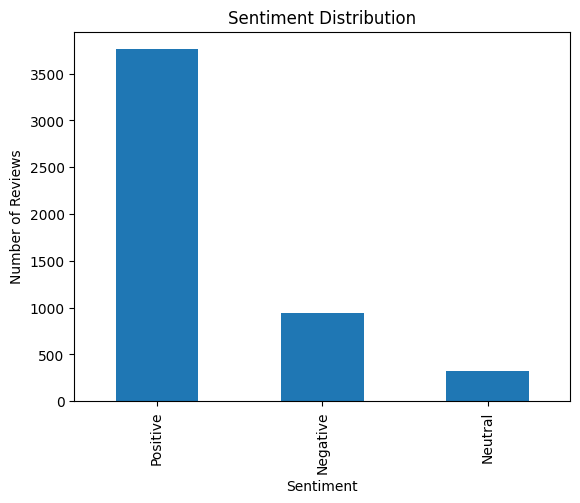

In [6]:
import matplotlib.pyplot as plt

# Đếm số lượng sentiment
df['sentiment'].value_counts().plot(kind='bar')

# Tiêu đề biểu đồ
plt.title("Sentiment Distribution")

# Nhãn trục X
plt.xlabel("Sentiment")

# Nhãn trục Y
plt.ylabel("Number of Reviews")

# Hiển thị biểu đồ
plt.show()

In [7]:
# So sánh rating với sentiment
pd.crosstab(df['rating'], df['sentiment'])

sentiment,Negative,Neutral,Positive
rating,,,
1,447,101,500
2,127,29,173
3,126,56,302
4,118,55,528
5,128,82,2258


In [8]:
negative_reviews = df[df['sentiment'] == 'Negative']
negative_reviews['processed_text'].head()

,processed_text
9,get top tournament diamond tournament blame bad
12,seem like owl lot error maybe learn voice part...
14,past wasnt good study use become much well good
16,almost legendary suddenly run energy wrong min...
19,since event reload go keep study energy featur...


In [9]:
from collections import Counter

words = " ".join(negative_reviews['processed_text']).split()
Counter(words).most_common(20)

[('learn', 347),
 ('study', 233),
 ('time', 231),
 ('use', 200),
 ('error', 196),
 ('word', 194),
 ('bad', 188),
 ('still', 187),
 ('lesson', 169),
 ('money', 163),
 ('get', 157),
 ('wrong', 153),
 ('lose', 139),
 ('day', 137),
 ('say', 135),
 ('like', 121),
 ('many', 107),
 ('read', 106),
 ('go', 103),
 ('download', 102)]

### Topic Modeling

In [10]:
# xử lý dữ liệu
import pandas as pd
import numpy as np

# xử lý text
import re
from nltk.corpus import stopwords

# topic modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

### Topic Modeling for Positive Reviews

In [11]:
# Install gensim if not already installed
!pip install gensim

# Select positive reviews for topic modeling
positive_reviews = df[df['sentiment'] == 'Positive']['lemmatized']

# Import gensim.corpora
from gensim import corpora
import gensim # Ensure gensim is imported for LdaModel

# Create a dictionary from the lemmatized positive reviews
pos_dictionary = corpora.Dictionary(positive_reviews)

# Convert each document into bag-of-words format
pos_corpus = [pos_dictionary.doc2bow(text) for text in positive_reviews]

# Train LDA model to discover topics for positive reviews
pos_lda = gensim.models.LdaModel(
    corpus=pos_corpus,       # bag-of-words data
    id2word=pos_dictionary,  # dictionary mapping
    num_topics=3,            # number of topics to extract
    random_state=42,         # reproducibility
    passes=10                # number of training passes
)

# Print discovered topics for positive reviews
print("Positive Review Topics:")
for topic in pos_lda.print_topics():
    print(topic)

Positive Review Topics:
(0, '0.027*"use" + 0.026*"word" + 0.012*"good" + 0.011*"learn" + 0.011*"feature" + 0.011*"like" + 0.011*"add" + 0.010*"look" + 0.010*"application" + 0.009*"translation"')
(1, '0.070*"learn" + 0.037*"good" + 0.026*"english" + 0.021*"application" + 0.021*"help" + 0.020*"like" + 0.016*"vocabulary" + 0.015*"word" + 0.014*"language" + 0.014*"many"')
(2, '0.021*"study" + 0.016*"learn" + 0.015*"lesson" + 0.015*"time" + 0.013*"money" + 0.012*"still" + 0.012*"like" + 0.012*"free" + 0.011*"use" + 0.011*"hope"')


### Formatted Topics for Positive Reviews

In [12]:
import pprint

print("Positive Review Topics:")
for topic_id, topic in pos_lda.show_topics(formatted=False, num_words=10):
    print(f"Topic {topic_id}:")
    pprint.pprint([(word, round(weight, 4)) for word, weight in topic])
    print()

Positive Review Topics:
Topic 0:
[('use', np.float32(0.0275)),
 ('word', np.float32(0.0264)),
 ('good', np.float32(0.0119)),
 ('learn', np.float32(0.0113)),
 ('feature', np.float32(0.0106)),
 ('like', np.float32(0.0106)),
 ('add', np.float32(0.0105)),
 ('look', np.float32(0.0104)),
 ('application', np.float32(0.0098)),
 ('translation', np.float32(0.0094))]

Topic 1:
[('learn', np.float32(0.0704)),
 ('good', np.float32(0.0374)),
 ('english', np.float32(0.0259)),
 ('application', np.float32(0.0214)),
 ('help', np.float32(0.0211)),
 ('like', np.float32(0.0201)),
 ('vocabulary', np.float32(0.0156)),
 ('word', np.float32(0.0145)),
 ('language', np.float32(0.0137)),
 ('many', np.float32(0.0137))]

Topic 2:
[('study', np.float32(0.0207)),
 ('learn', np.float32(0.0161)),
 ('lesson', np.float32(0.0151)),
 ('time', np.float32(0.0149)),
 ('money', np.float32(0.0135)),
 ('still', np.float32(0.0124)),
 ('like', np.float32(0.0123)),
 ('free', np.float32(0.0116)),
 ('use', np.float32(0.0108)),
 ('hop

### Word Clouds for Positive Reviews

In [13]:
# Install wordcloud library if not already installed
!pip install wordcloud

Generating word clouds for Positive Review Topics...


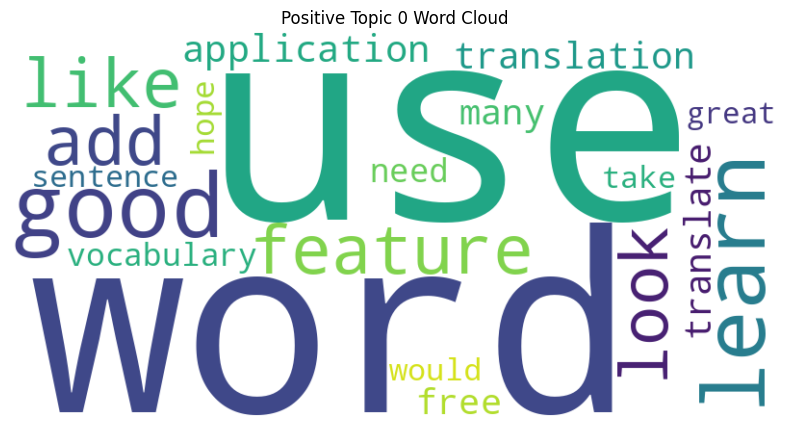

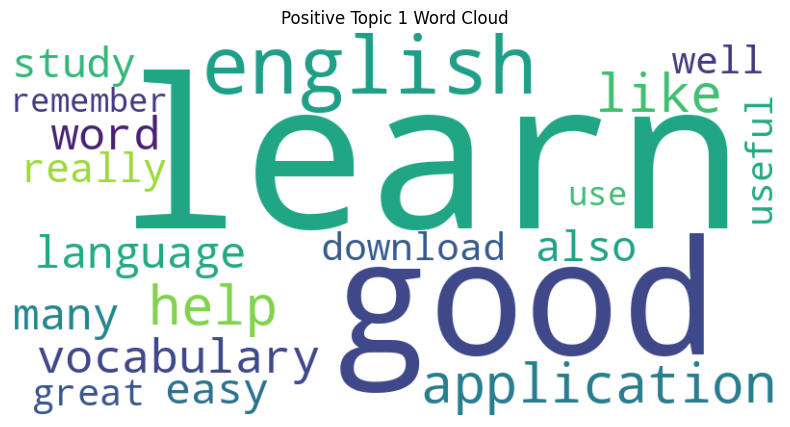

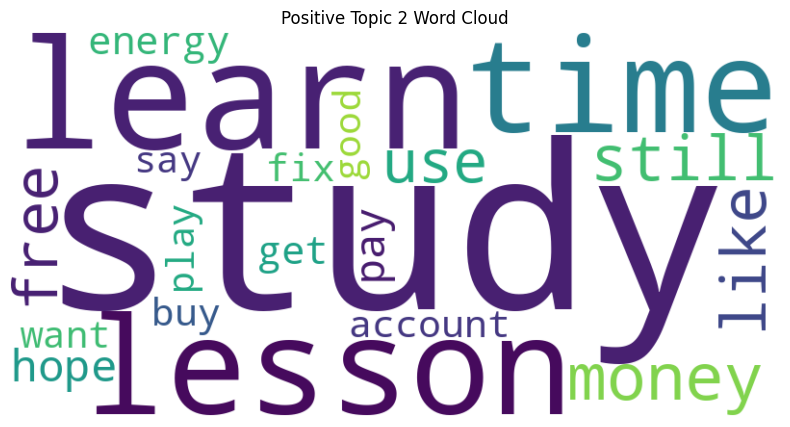

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word clouds for positive topics
print("Generating word clouds for Positive Review Topics...")

for topic_id, topic in pos_lda.show_topics(formatted=False, num_words=20):
    # Create a dictionary of word and their weights for the current topic
    topic_words = dict(topic)

    # Generate word cloud
    wordcloud = WordCloud(
        background_color="white",
        width=800,
        height=400,
        max_words=20,
        colormap='viridis',
        random_state=42
    ).generate_from_frequencies(topic_words)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Positive Topic {topic_id} Word Cloud")
    plt.show()
    print() # Add a newline for better separation

### Topic Modeling for Negative Reviews

In [15]:
# Select negative reviews for topic modeling
negative_reviews = df[df['sentiment'] == 'Negative']['lemmatized']

# Create a dictionary from the lemmatized negative reviews
neg_dictionary = corpora.Dictionary(negative_reviews)

# Convert each document into bag-of-words format
neg_corpus = [neg_dictionary.doc2bow(text) for text in negative_reviews]

# Train LDA model to discover topics for negative reviews
neg_lda = gensim.models.LdaModel(
    corpus=neg_corpus,       # bag-of-words data
    id2word=neg_dictionary,  # dictionary mapping
    num_topics=3,            # number of topics to extract
    random_state=42,         # reproducibility
    passes=10                # number of training passes
)

# Print discovered topics for negative reviews
print("Negative Review Topics:")
for topic in neg_lda.print_topics():
    print(topic)

Negative Review Topics:
(0, '0.017*"lose" + 0.016*"use" + 0.016*"bad" + 0.014*"study" + 0.013*"log" + 0.012*"time" + 0.011*"package" + 0.010*"word" + 0.009*"like" + 0.009*"translation"')
(1, '0.035*"learn" + 0.016*"time" + 0.015*"study" + 0.014*"lesson" + 0.013*"wrong" + 0.013*"still" + 0.013*"error" + 0.012*"word" + 0.012*"say" + 0.011*"day"')
(2, '0.020*"money" + 0.012*"use" + 0.011*"error" + 0.010*"still" + 0.010*"bad" + 0.009*"part" + 0.009*"see" + 0.008*"fix" + 0.008*"word" + 0.008*"make"')


### Formatted Topics for Negative Reviews

In [16]:
import pprint

print("Negative Review Topics:")
for topic_id, topic in neg_lda.show_topics(formatted=False, num_words=10):
    print(f"Topic {topic_id}:")
    pprint.pprint([(word, round(weight, 4)) for word, weight in topic])
    print()

Negative Review Topics:
Topic 0:
[('lose', np.float32(0.0174)),
 ('use', np.float32(0.0159)),
 ('bad', np.float32(0.0158)),
 ('study', np.float32(0.0139)),
 ('log', np.float32(0.0126)),
 ('time', np.float32(0.0124)),
 ('package', np.float32(0.011)),
 ('word', np.float32(0.0096)),
 ('like', np.float32(0.0094)),
 ('translation', np.float32(0.0094))]

Topic 1:
[('learn', np.float32(0.0346)),
 ('time', np.float32(0.0165)),
 ('study', np.float32(0.0148)),
 ('lesson', np.float32(0.0139)),
 ('wrong', np.float32(0.013)),
 ('still', np.float32(0.0128)),
 ('error', np.float32(0.0127)),
 ('word', np.float32(0.0123)),
 ('say', np.float32(0.0121)),
 ('day', np.float32(0.0113))]

Topic 2:
[('money', np.float32(0.0202)),
 ('use', np.float32(0.0116)),
 ('error', np.float32(0.0107)),
 ('still', np.float32(0.0099)),
 ('bad', np.float32(0.0098)),
 ('part', np.float32(0.0094)),
 ('see', np.float32(0.0086)),
 ('fix', np.float32(0.0084)),
 ('word', np.float32(0.0084)),
 ('make', np.float32(0.0082))]



### Word Clouds for Negative Reviews

Generating word clouds for Negative Review Topics...


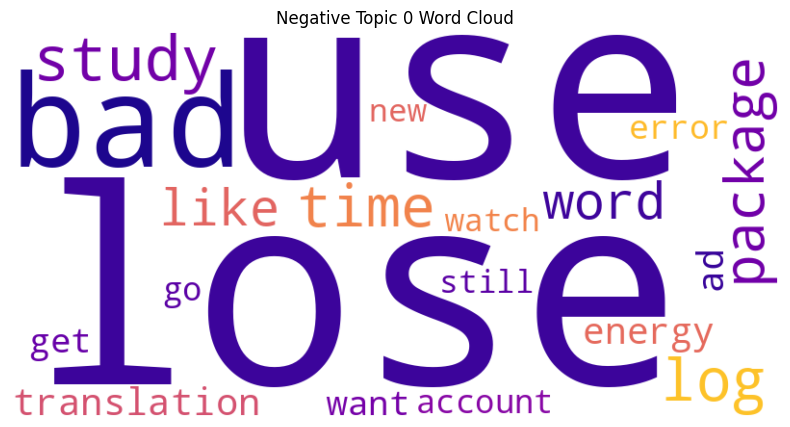

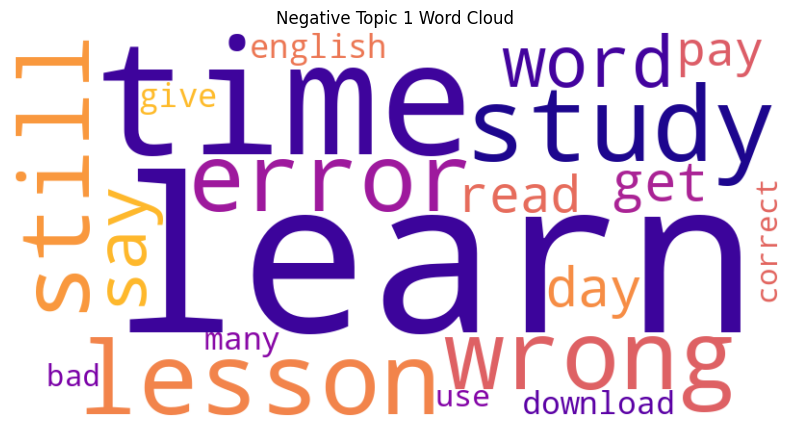

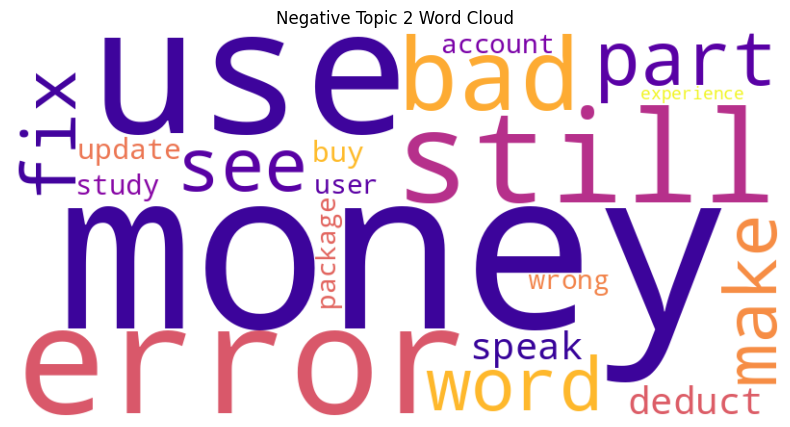

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word clouds for negative topics
print("Generating word clouds for Negative Review Topics...")

for topic_id, topic in neg_lda.show_topics(formatted=False, num_words=20):
    # Create a dictionary of word and their weights for the current topic
    topic_words = dict(topic)

    # Generate word cloud
    wordcloud = WordCloud(
        background_color="white",
        width=800,
        height=400,
        max_words=20,
        colormap='plasma',
        random_state=42
    ).generate_from_frequencies(topic_words)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Negative Topic {topic_id} Word Cloud")
    plt.show()
    print() # Add a newline for better separation